In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("wtbdata_245days.csv")
print("Raw data shape:", df.shape)

Raw data shape: (4727520, 13)


In [ ]:
print("=== Step 1: Remove missing values ===")
df = df.dropna()
print("After dropna:", df.shape)

print("\n=== Step 2: Remove negative/zero wind speed ===")
df = df[df["Wspd"] > 0]
print("After Wspd filter:", df.shape)

print("\n=== Step 3: Remove negative power ===")
# Power output physically cannot be negative
df = df[df["Patv"] >= 0]
print("After Patv filter:", df.shape)

print("\n=== Step 4: Remove shutdowns ===")
# Wind > 3 m/s but power = 0 → turbine was shut down or faulty
df = df[~((df["Wspd"] > 3) & (df["Patv"] == 0))]
print("After shutdown filter:", df.shape)

print("\n=== Step 5: Drop ID and timestamp columns ===")
# TurbID is just an ID, Day & Tmstamp are time markers — not useful for ML
df = df.drop(columns=["TurbID", "Day", "Tmstamp"])
print("Final shape:", df.shape)

=== Step 1: Remove missing values ===
After dropna: (4678002, 13)

=== Step 2: Remove negative/zero wind speed ===
After Wspd filter: (4665333, 13)

=== Step 3: Remove negative power ===
After Patv filter: (3402556, 13)

=== Step 4: Remove shutdowns ===
After shutdown filter: (3373786, 13)

=== Step 5: Drop ID and timestamp columns ===
Final shape: (3373786, 10)


In [3]:
# Yaw error = how misaligned the turbine is from the wind direction
# The smaller this is, the more power the turbine captures
df["yaw_error"] = abs(df["Wdir"] - df["Ndir"])

# Normalize yaw error to 0-180 degrees
df["yaw_error"] = df["yaw_error"].apply(lambda x: x if x <= 180 else 360 - x)

print("Yaw error feature added ✅")
print(df[["Wdir", "Ndir", "yaw_error"]].head())

Yaw error feature added ✅
   Wdir   Ndir  yaw_error
1 -3.99  25.92      29.91
2 -2.18  20.91      23.09
3 -0.73  20.91      21.64
4  0.89  20.91      20.02
5 -1.03  20.91      21.94


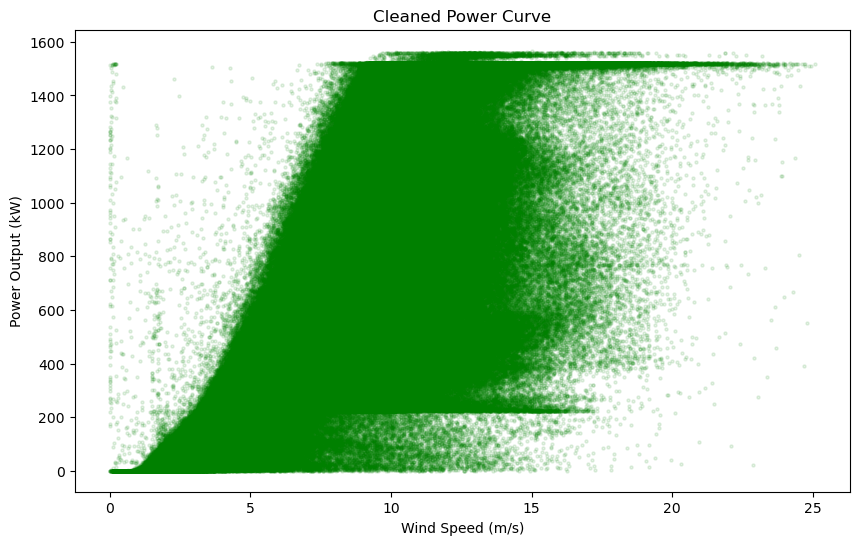

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Wspd"], df["Patv"], alpha=0.1, s=5, color='green')
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.title("Cleaned Power Curve")
plt.savefig("02_cleaned_power_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df.to_csv("cleaned_data.csv", index=False)
print("Cleaned data saved ✅")
print("Final columns:", df.columns.tolist())

Cleaned data saved ✅
Final columns: ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv', 'Patv', 'yaw_error']
